# Phase 4: Advanced Checks — What Separates Good Analysts from Great Ones

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('search_experiment.csv')
control   = df[df['group'] == 'control']
treatment = df[df['group'] == 'treatment']

print("Data loaded successfully")
print(f"Total rows: {len(df)}")

Data loaded successfully
Total rows: 20013


## Novelty Effect: CTR by week:

In [2]:
# Assign each day to a week
df['week'] = pd.cut(df['day'], bins=[0,7,14,21], labels=['Week 1','Week 2','Week 3'])

weekly_ctr = df.groupby(['week','group'])['clicked'].mean().mul(100).round(2).reset_index()
weekly_ctr.columns = ['week','group','ctr']

print("=== CTR by Week ===")
print(weekly_ctr.pivot(index='week', columns='group', values='ctr'))
weekly_ctr.to_csv('result_weekly_ctr.csv', index=False)

=== CTR by Week ===
group   control  treatment
week                      
Week 1    50.36      54.26
Week 2    47.59      55.25
Week 3    47.51      55.17


## Novelty Effect: Plot CTR over all 21 days:

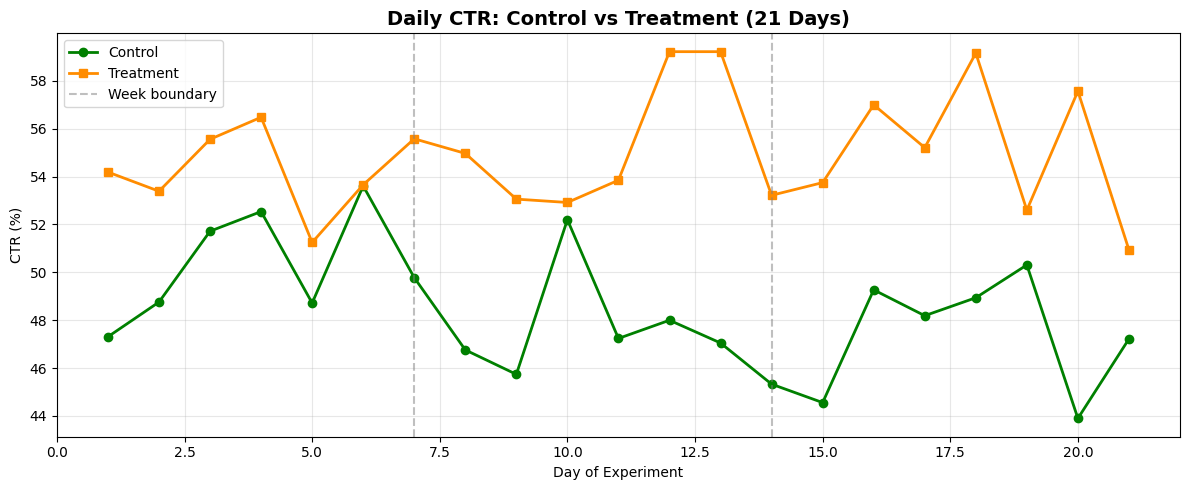

Plot saved.


In [7]:
daily = df.groupby(['day','group'])['clicked'].mean().mul(100).round(2).reset_index()

ctrl_daily  = daily[daily['group']=='control']
treat_daily = daily[daily['group']=='treatment']

plt.figure(figsize=(12,5))
plt.plot(ctrl_daily['day'],  ctrl_daily['clicked'],  marker='o', label='Control',   color='green',  linewidth=2)
plt.plot(treat_daily['day'], treat_daily['clicked'], marker='s', label='Treatment', color='darkorange', linewidth=2)

# Week dividers
plt.axvline(x=7,  color='gray', linestyle='--', alpha=0.5, label='Week boundary')
plt.axvline(x=14, color='gray', linestyle='--', alpha=0.5)

plt.title('Daily CTR: Control vs Treatment (21 Days)', fontsize=14, fontweight='bold')
plt.xlabel('Day of Experiment')
plt.ylabel('CTR (%)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('novelty_effect_plot.png', dpi=150)
plt.show()
print("Plot saved.")

## Novelty Effect: Weekly gap analysis:

In [4]:
pivot = weekly_ctr.pivot(index='week', columns='group', values='ctr')
pivot['gap'] = (pivot['treatment'] - pivot['control']).round(2)

print("=== Weekly CTR Gap (Treatment - Control) ===")
print(pivot)
print()

w1_gap = pivot.loc['Week 1','gap']
w3_gap = pivot.loc['Week 3','gap']
fade   = ((w1_gap - w3_gap) / w1_gap * 100).round(1)

print(f"Week 1 gap : {w1_gap}%")
print(f"Week 3 gap : {w3_gap}%")
print(f"Gap faded by: {fade}%")
print()
if fade > 50:
    print("WARNING: Strong novelty effect detected. Week 3 gap is less than half of Week 1.")
elif fade > 20:
    print("MODERATE: Some novelty effect present but treatment still outperforms in Week 3.")
else:
    print("GOOD: No significant novelty effect. Treatment advantage is consistent across all weeks.")

=== Weekly CTR Gap (Treatment - Control) ===
group   control  treatment   gap
week                            
Week 1    50.36      54.26  3.90
Week 2    47.59      55.25  7.66
Week 3    47.51      55.17  7.66

Week 1 gap : 3.9%
Week 3 gap : 7.66%
Gap faded by: -96.4%

GOOD: No significant novelty effect. Treatment advantage is consistent across all weeks.


## Sample Ratio Mismatch (SRM):

In [5]:
# We expected exactly 50/50 split
total         = len(df['user_id'].unique())
control_users = df[df['group']=='control']['user_id'].nunique()
treat_users   = df[df['group']=='treatment']['user_id'].nunique()
expected      = total / 2

print("=== Sample Ratio Mismatch Check ===")
print(f"Total users    : {total}")
print(f"Control users  : {control_users}  (expected {expected:.0f})")
print(f"Treatment users: {treat_users}  (expected {expected:.0f})")
print()

# Chi-square test on user counts
chi2_srm, p_srm = stats.chisquare([control_users, treat_users], f_exp=[expected, expected])

print(f"Chi2 statistic : {chi2_srm:.4f}")
print(f"P-value        : {p_srm:.4f}")
print()
if p_srm < 0.05:
    print("WARNING: SRM detected! Randomization may be broken. Results should be treated with caution.")
else:
    print("GOOD: No SRM detected. The 50/50 split is within acceptable random variation.")
    print("Our experiment randomization is valid.")

=== Sample Ratio Mismatch Check ===
Total users    : 10000
Control users  : 5013  (expected 5000)
Treatment users: 4987  (expected 5000)

Chi2 statistic : 0.0676
P-value        : 0.7949

GOOD: No SRM detected. The 50/50 split is within acceptable random variation.
Our experiment randomization is valid.


## Practical Significance: Confidence Interval on CTR:

In [6]:
# Calculate confidence interval for CTR difference
n_ctrl  = len(control)
n_treat = len(treatment)
p_ctrl  = control['clicked'].mean()
p_treat = treatment['clicked'].mean()

diff    = p_treat - p_ctrl
se      = np.sqrt((p_ctrl*(1-p_ctrl)/n_ctrl) + (p_treat*(1-p_treat)/n_treat))
z       = 1.96  # 95% confidence level

lower = (diff - z * se) * 100
upper = (diff + z * se) * 100

print("=== Practical Significance: 95% Confidence Interval ===")
print(f"Control CTR    : {p_ctrl*100:.2f}%")
print(f"Treatment CTR  : {p_treat*100:.2f}%")
print(f"Observed lift  : {diff*100:.2f}%")
print()
print(f"95% CI: [{lower:.2f}%, {upper:.2f}%]")
print()
print(f"Interpretation: We are 95% confident the true CTR improvement")
print(f"from shipping this algorithm is between {lower:.2f}% and {upper:.2f}%.")
print()
if lower > 1.0:
    print("SHIP IT: Even the conservative lower bound shows a meaningful improvement.")
elif lower > 0:
    print("BORDERLINE: Improvement is real but the lower bound is small. Consider longer test.")
else:
    print("CAUTION: Confidence interval crosses zero. Cannot confidently claim positive impact.")

=== Practical Significance: 95% Confidence Interval ===
Control CTR    : 48.48%
Treatment CTR  : 54.89%
Observed lift  : 6.41%

95% CI: [5.02%, 7.79%]

Interpretation: We are 95% confident the true CTR improvement
from shipping this algorithm is between 5.02% and 7.79%.

SHIP IT: Even the conservative lower bound shows a meaningful improvement.
